In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
sys.path.append(os.path.abspath(".."))

from src.utils.rate_utils import GetRates
from src.assets.bond import Bond
from src.assets.portfolio import BondPortfolio
from src.assets.pricing import price_bond
from src.liabilities.deposit_model import DepositModel
from src.liabilities.cashflow_generator import present_value
from src.rates.hull_white import HullWhite
from src.risk.monte_carlo import MonteCarlo
from src.risk.stress_testing import StressTesting

In [2]:
# loading yield curves
df = pd.read_csv(
    "../data/processed/cleaned_yield_curve_fred.csv",
    index_col = 'date',
    parse_dates = True
)

# extracting latest yield curve
curve = GetRates().get_latest_curve(df)

# extracting initial short rate
r0 = GetRates().get_short_rate(curve)

# building balance sheet components
### -- ASSETS --
bonds = [
    Bond(face_value=1000, coupon_rate=0.02, maturity=3),
    Bond(face_value=1000, coupon_rate=0.03, maturity=5),
    Bond(face_value=1000, coupon_rate=0.04, maturity=10)
]

bond_portfolio = BondPortfolio(bonds)

### -- LIABILITIES --
deposit_model = DepositModel(initial_amount=11700, decay_rate=0.965)

# initializing HW model
theta = float(np.mean(list(curve.values())))

HW_model = HullWhite(
    a = 0.1,
    sigma = 0.01,
    initial_rate = r0,
    theta = theta
)

# simulating interest rate paths
ir_paths = HW_model.simulate_paths(
    n_paths = 1000,
    n_steps = 60,
    dt = 1.0
)

print(f"Interest Rate Paths Shape (n_paths, n_steps): {ir_paths.shape}")

Interest Rate Paths Shape (n_paths, n_steps): (1000, 60)


In [3]:
# running monte carlo simulation
alm_mc = MonteCarlo(
    portfolio = bond_portfolio,
    deposit_model = deposit_model,
    pricing_function = price_bond,
    liability_pv_function = present_value
)

results = alm_mc.run_simulation(
    rate_paths = ir_paths,
    dt = 1.0
)

df_results = pd.DataFrame(results)
df_results

,assets,liabilities,equity,funding_ratio,asset_duration,liability_duration,duration_gap
0,2661.945252,2663.214543,-1.269291,0.999523,5.287496,4.760704,0.526792
1,2807.320408,2793.912580,13.407828,1.004799,5.368330,4.840061,0.528269
2,2951.819847,2923.321771,28.498077,1.009749,5.444938,4.914451,0.530487
3,3056.668980,3016.913333,39.755646,1.013178,5.498343,4.965857,0.532485
4,2942.474377,2914.967214,27.507163,1.009437,5.440091,4.909767,0.530324
...,...,...,...,...,...,...,...
995,3235.673457,3176.110800,59.562656,1.018753,5.585566,5.049054,0.536512
996,2885.742656,2864.206599,21.536057,1.007519,5.410352,4.880962,0.529390
997,2743.840326,2736.904213,6.936114,1.002534,5.333513,4.805992,0.527522
998,2587.066367,2595.695291,-8.628924,0.996676,5.244293,4.717911,0.526381


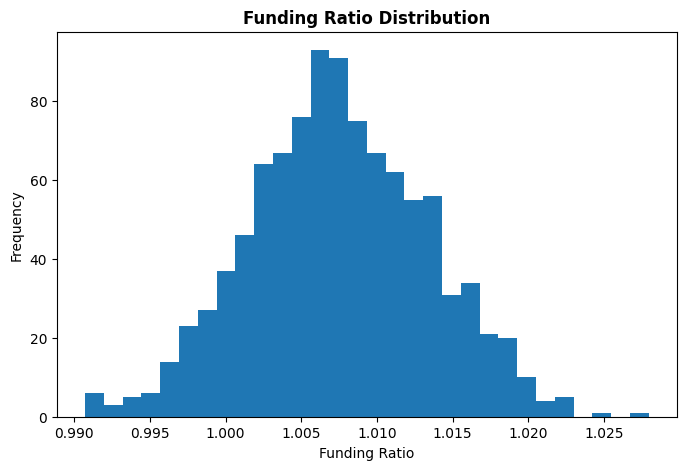

In [4]:
# funding ration distribution
plt.figure(figsize=(8, 5))
plt.hist(df_results['funding_ratio'], bins = 30)

plt.title('Funding Ratio Distribution', fontweight = 'bold')
plt.xlabel('Funding Ratio')
plt.ylabel('Frequency')
plt.show()

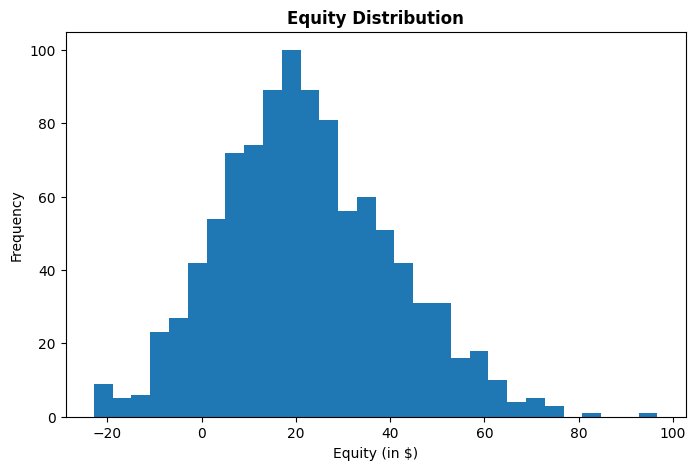

In [5]:
# equity distribution
plt.figure(figsize=(8, 5))
plt.hist(df_results['equity'], bins = 30)

plt.title('Equity Distribution', fontweight = 'bold')
plt.xlabel('Equity (in $)')
plt.ylabel('Frequency')
plt.show()

In [6]:
# probability of underfunding
prob_underfunding = float((df_results['funding_ratio'] < 1).mean())
print(f"Probability of Underfunding: {prob_underfunding:.2f}")

Probability of Underfunding: 0.09


In [7]:
# Value-at-Risk - the maximum loss expected with 95% confidence
var_95 = np.percentile(df_results['equity'], 5)
print(f"Equity VaR (95%): {var_95:.2f}")

# worst-case scenario respect to the lowest 10 equities
df_results.nsmallest(10, 'equity')

Equity VaR (95%): -5.85


,assets,liabilities,equity,funding_ratio,asset_duration,liability_duration,duration_gap
67,2438.283159,2461.126866,-22.843706,0.990718,5.155076,4.628673,0.526403
786,2440.807196,2463.414317,-22.607122,0.990823,5.156628,4.630236,0.526392
285,2444.204259,2466.492715,-22.288456,0.990964,5.158716,4.632337,0.526379
576,2453.275863,2474.711944,-21.436081,0.991338,5.164277,4.637932,0.526345
874,2454.486312,2475.808504,-21.322192,0.991388,5.165018,4.638677,0.526341
777,2460.395925,2481.161571,-20.765646,0.991631,5.168630,4.642307,0.526322
709,2469.113741,2489.056795,-19.943054,0.991988,5.173945,4.647646,0.526298
501,2471.828791,2491.515274,-19.686484,0.992099,5.175597,4.649305,0.526292
169,2474.023641,2493.502580,-19.478939,0.992188,5.176931,4.650644,0.526287
987,2499.575669,2516.629644,-17.053975,0.993223,5.192389,4.666140,0.526249


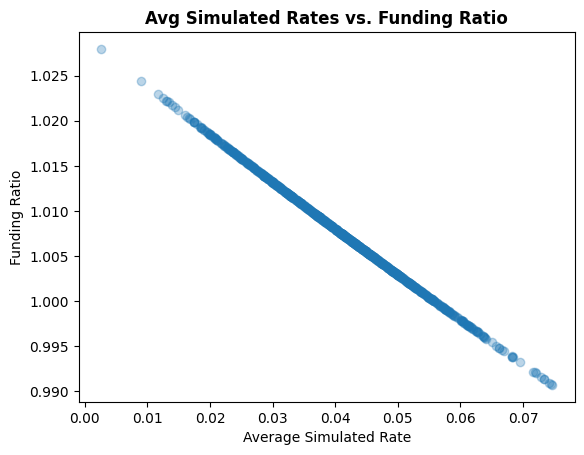

In [8]:
# rates vs. funding ratio
avg_rates_per_step = ir_paths.mean(axis = 1)
plt.scatter(avg_rates_per_step, df_results['funding_ratio'], alpha = 0.3)
plt.xlabel('Average Simulated Rate')
plt.ylabel('Funding Ratio')
plt.title('Avg Simulated Rates vs. Funding Ratio', fontweight = 'bold')
plt.show()

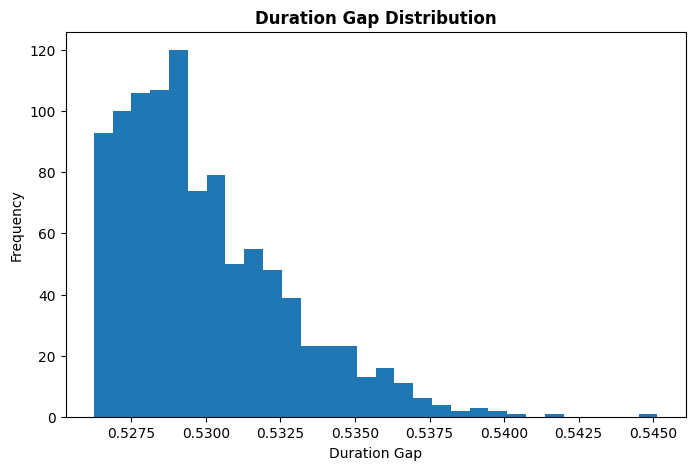

In [10]:
# duration gap distribution
plt.figure(figsize=(8, 5))
plt.hist(df_results['duration_gap'], bins = 30)
plt.title('Duration Gap Distribution', fontweight = 'bold')
plt.xlabel('Duration Gap')
plt.ylabel('Frequency')
plt.show()

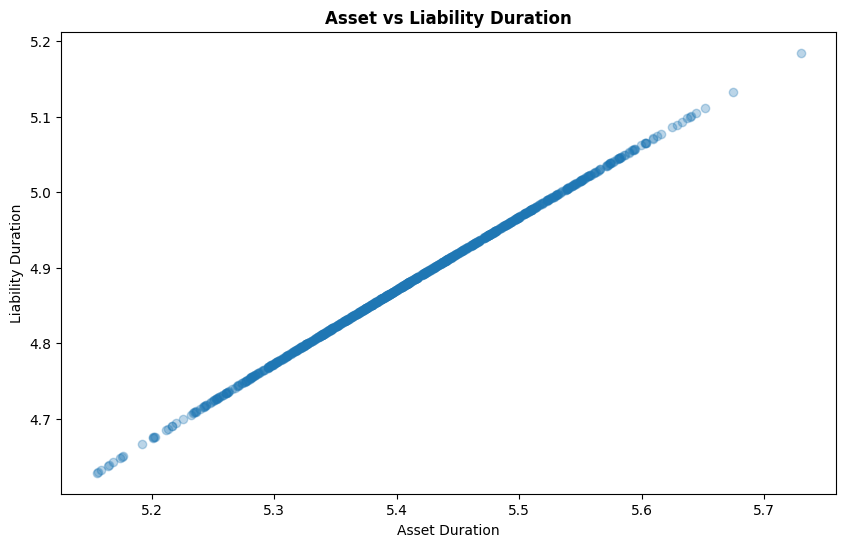

In [12]:
# assets vs liabilities duration
plt.figure(figsize=(10, 6))
plt.scatter(
    df_results['asset_duration'],
    df_results['liability_duration'],
    alpha = 0.3
)

plt.xlabel('Asset Duration')
plt.ylabel('Liability Duration')
plt.title('Asset vs Liability Duration', fontweight = 'bold')
plt.show()

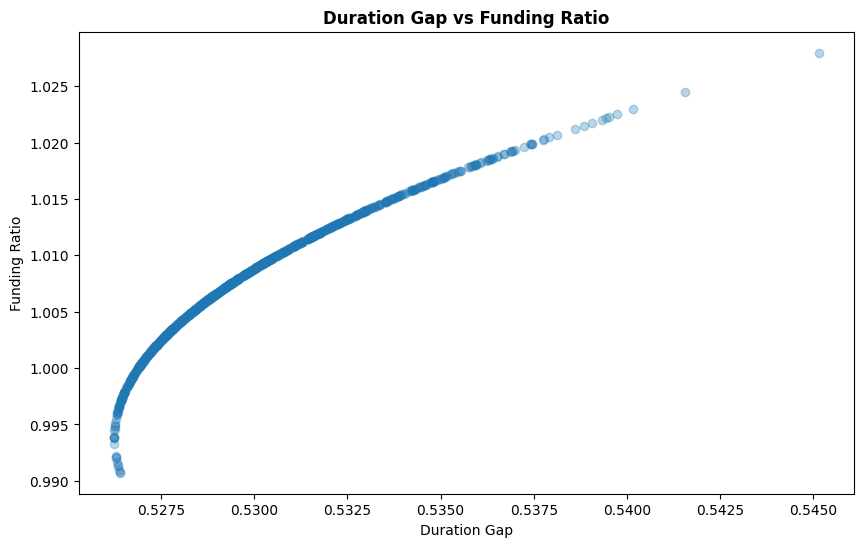

In [13]:
# duration gap vs funding ratio
plt.figure(figsize=(10, 6))
plt.scatter(
    df_results['duration_gap'],
    df_results['funding_ratio'],
    alpha = 0.3
)

plt.xlabel('Duration Gap')
plt.ylabel('Funding Ratio')
plt.title('Duration Gap vs Funding Ratio', fontweight = 'bold')
plt.show()

In [15]:
# initializing stress testing object
stress_testing = StressTesting(curve)

stress_results = stress_testing.run_stress_test(
    portfolio = bond_portfolio,
    deposit_model = deposit_model,
    pricing_function = price_bond,
    liability_pv_function = present_value
)

df_stress = pd.DataFrame(stress_results)
df_stress

,scenario,assets,liabilities,equity,funding_ratio
0,Base,2874.042060,2856.177258,17.864802,1.006255
1,Parallel Up +200bps,2598.675226,2607.973996,-9.298771,0.996434
2,Parallel Down -200bps,3194.411692,3142.760350,51.651341,1.016435
3,Steepener,2675.372017,2677.412359,-2.040342,0.999238
4,Flattener,2723.156936,2719.440904,3.716033,1.001366


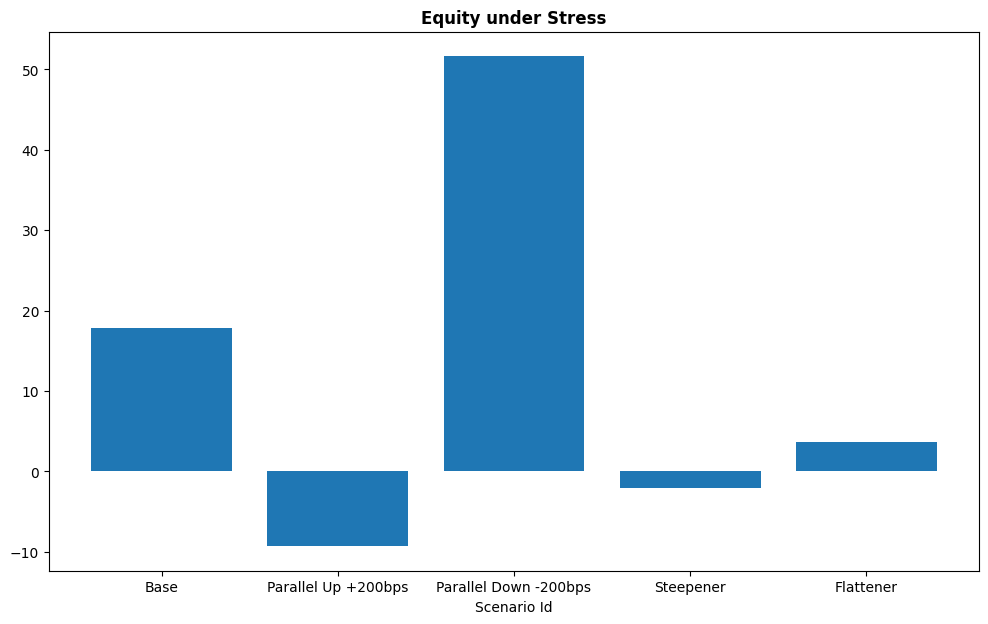

In [28]:
# equity under stress
plt.figure(figsize=(12, 7))
plt.bar(
    df_stress['scenario'],
    df_stress['equity']
)
plt.xlabel('Scenario Id')
plt.title('Equity under Stress', fontweight = 'bold')
plt.show()

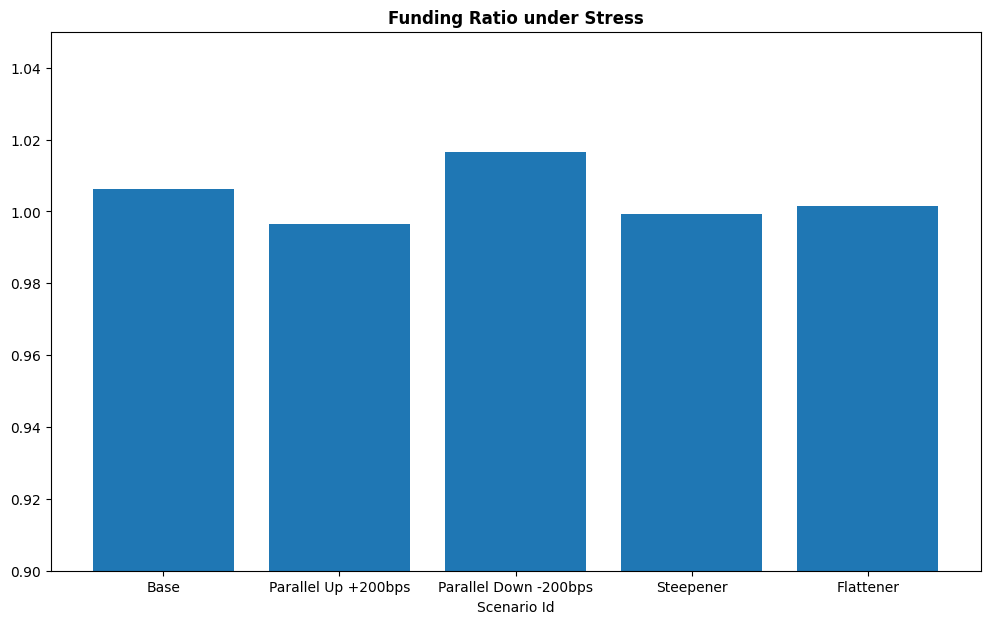

In [33]:
# funding ratio under stress
plt.figure(figsize=(12, 7))
plt.bar(
    df_stress['scenario'],
    df_stress['funding_ratio']    
)

plt.xlabel('Scenario Id')
plt.title('Funding Ratio under Stress', fontweight = 'bold')
plt.ylim(0.9, 1.05)
plt.show()